# DS605: Fundamentals of Machine Learning — Lab Assignment 6
## Feature Extraction and Machine Learning with Image and Text Data


In [17]:
from pathlib import Path
import time
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

RANDOM_STATE = 42
ROOT = Path.cwd()
IMAGE_DIR = ROOT / 'data' / 'images'
TEXT_DIR = ROOT / 'data' / 'text'
OUTPUT_DIR = ROOT / 'outputs'
VIS_DIR = OUTPUT_DIR / 'image_visualizations'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR = OUTPUT_DIR / 'figures'
for p in [VIS_DIR, TABLE_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Working directory:', ROOT)
print('Image directory:', IMAGE_DIR)
print('Text directory:', TEXT_DIR)

Working directory: d:\College work\PG\Sem 1\ML\Lec\202618061_VedantKapur_DS605\202618061_Lab_6
Image directory: d:\College work\PG\Sem 1\ML\Lec\202618061_VedantKapur_DS605\202618061_Lab_6\data\images
Text directory: d:\College work\PG\Sem 1\ML\Lec\202618061_VedantKapur_DS605\202618061_Lab_6\data\text


# Part A — Image Feature Extraction and Classification
The assignment requires common image dimensions, grayscale representations, NumPy intensity features, and Canny edge features.

In [18]:
IMAGE_SIZE = (128, 128)

def infer_image_label(path: Path):
    # First preference: parent folder name.
    parent = path.parent.name.lower().replace('_', '-').replace(' ', '-')
    if any(k in parent for k in ['non-crack', 'noncrack', 'without-crack', 'no-crack']):
        return 0
    if 'crack' in parent:
        return 1

    # Filename fallback.
    name = path.stem.lower().replace('_', '-').replace(' ', '-')
    if any(k in name for k in ['non-crack', 'noncrack', 'without-crack', 'no-crack']):
        return 0
    if 'crack' in name:
        return 1

    # Common numeric filename conventions: 1/crack vs 0/non-crack.
    if re.search(r'(?:^|[-_])1(?:[-_]|$)', name):
        return 1
    if re.search(r'(?:^|[-_])0(?:[-_]|$)', name):
        return 0
    return None

def collect_image_paths(root):
    extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
    return sorted([p for p in root.rglob('*') if p.suffix.lower() in extensions])

image_paths = collect_image_paths(IMAGE_DIR)
if not image_paths:
    raise FileNotFoundError('No image files found. Put the Asphalt Crack images inside data/images/.')

image_labels = [infer_image_label(p) for p in image_paths]
known = [(p, y) for p, y in zip(image_paths, image_labels) if y is not None]
if not known:
    raise ValueError('Could not infer crack/non-crack labels. Use crack/non-crack folders or filenames containing crack/non-crack.')

image_paths = [p for p, y in known]
image_labels = np.array([y for p, y in known], dtype=int)
print('Images found:', len(image_paths))
print('Class distribution:', pd.Series(image_labels).value_counts().sort_index().to_dict())

Images found: 400
Class distribution: {0: 200, 1: 200}


In [19]:
def image_features(path, size=IMAGE_SIZE, canny_low=50, canny_high=150):
    img = Image.open(path).convert('RGB')
    original_w, original_h = img.size
    arr = np.asarray(img)
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)

    g = gray.astype(np.float32)
    mean_brightness = float(g.mean())
    std_contrast = float(g.std())
    median_intensity = float(np.median(g))
    min_intensity = float(g.min())
    max_intensity = float(g.max())
    dark_ratio = float((g < 50).mean())
    bright_ratio = float((g > 200).mean())
    q25, q75 = np.percentile(g, [25, 75])
    iqr = float(q75 - q25)

    edges = cv2.Canny(gray, canny_low, canny_high)
    edge_count = int(np.count_nonzero(edges))
    edge_density = float(edge_count / edges.size)

    return {
        'filename': path.name,
        'original_width': original_w,
        'original_height': original_h,
        'mean_brightness': mean_brightness,
        'std_contrast': std_contrast,
        'median_intensity': median_intensity,
        'min_intensity': min_intensity,
        'max_intensity': max_intensity,
        'dark_pixel_ratio': dark_ratio,
        'bright_pixel_ratio': bright_ratio,
        'intensity_iqr': iqr,
        'edge_count': edge_count,
        'edge_density': edge_density
    }, gray, edges


In [9]:
rows = []
first_gray = first_edges = None
first_path = None

start = time.perf_counter()
for path, label in zip(image_paths, image_labels):
    feats, gray, edges = image_features(path)
    feats['label'] = label
    rows.append(feats)
    if first_gray is None:
        first_path, first_gray, first_edges = path, gray, edges
image_feature_df = pd.DataFrame(rows)
feature_csv = TABLE_DIR / 'image_features.csv'
image_feature_df.to_csv(feature_csv, index=False)
image_extraction_time = time.perf_counter() - start

print(f'Feature extraction time: {image_extraction_time:.4f} seconds')
print('Feature table shape:', image_feature_df.shape)
display(image_feature_df.head())
print('Saved:', feature_csv)

Feature extraction time: 3.5239 seconds
Feature table shape: (400, 14)


,filename,original_width,original_height,mean_brightness,std_contrast,median_intensity,min_intensity,max_intensity,dark_pixel_ratio,bright_pixel_ratio,intensity_iqr,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,448,448,122.095642,25.438692,120.0,43.0,241.0,0.000427,0.002625,33.0,5870,0.358276,1
1,IMG_20180513_165129852_HDR resized_448.jpg,448,448,131.822693,20.022919,133.0,31.0,223.0,0.001404,0.001038,23.0,5303,0.323669,1
2,IMG_20180513_165150613_HDR resized_448.jpg,448,448,121.174316,24.454477,120.0,10.0,224.0,0.006470,0.002014,25.0,4744,0.289551,1
3,IMG_20180513_165345878_HDR resized_448.jpg,448,448,130.117432,19.904099,131.0,37.0,250.0,0.000183,0.001465,25.0,5834,0.356079,1
4,IMG_20180513_165349788_HDR resized_448.jpg,448,448,131.084778,20.110945,132.0,40.0,249.0,0.000549,0.002747,23.0,5459,0.333191,1


Saved: d:\College work\PG\Sem 1\ML\Lec\202618061_VedantKapur_DS605\202618061_Lab_6\outputs\tables\image_features.csv


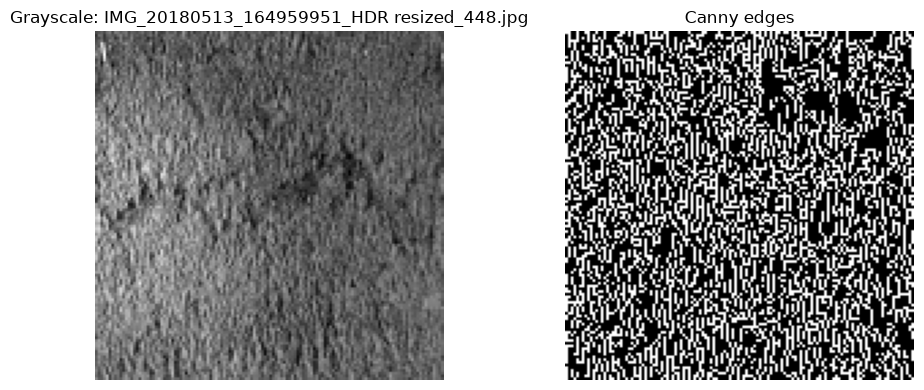

Saved: d:\College work\PG\Sem 1\ML\Lec\202618061_VedantKapur_DS605\202618061_Lab_6\outputs\image_visualizations\sample_grayscale_and_canny.png


In [10]:
if first_gray is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(first_gray, cmap='gray')
    axes[0].set_title(f'Grayscale: {first_path.name}')
    axes[0].axis('off')
    axes[1].imshow(first_edges, cmap='gray')
    axes[1].set_title('Canny edges')
    axes[1].axis('off')
    plt.tight_layout()
    viz_path = VIS_DIR / 'sample_grayscale_and_canny.png'
    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', viz_path)

In [11]:
IMAGE_FEATURES = [
    'mean_brightness', 'std_contrast', 'median_intensity',
    'min_intensity', 'max_intensity', 'dark_pixel_ratio',
    'bright_pixel_ratio', 'intensity_iqr', 'edge_count', 'edge_density'
]
X_img = image_feature_df[IMAGE_FEATURES].copy()
y_img = image_feature_df['label'].astype(int)

X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
    X_img, y_img, test_size=0.20, random_state=RANDOM_STATE, stratify=y_img
)

image_models = {
    'Logistic Regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
}

image_results = []
for name, model in image_models.items():
    t0 = time.perf_counter()
    model.fit(X_img_train, y_img_train)
    train_time = time.perf_counter() - t0
    t1 = time.perf_counter()
    pred = model.predict(X_img_test)
    predict_time = time.perf_counter() - t1
    cm = confusion_matrix(y_img_test, pred)
    image_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_img_test, pred),
        'Precision': precision_score(y_img_test, pred, zero_division=0),
        'Recall': recall_score(y_img_test, pred, zero_division=0),
        'F1': f1_score(y_img_test, pred, zero_division=0),
        'Training Time (s)': train_time,
        'Prediction Time (s)': predict_time
    })
    print('\n', name)
    print(classification_report(y_img_test, pred, target_names=['Non-crack','Crack'], zero_division=0))
    print('Confusion matrix:\n', cm)

image_results_df = pd.DataFrame(image_results)
image_results_df.to_csv(TABLE_DIR / 'image_model_results.csv', index=False)
display(image_results_df)


 Logistic Regression
              precision    recall  f1-score   support

   Non-crack       0.92      0.90      0.91        40
       Crack       0.90      0.93      0.91        40

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

Confusion matrix:
 [[36  4]
 [ 3 37]]

 Random Forest
              precision    recall  f1-score   support

   Non-crack       0.95      0.95      0.95        40
       Crack       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Confusion matrix:
 [[38  2]
 [ 2 38]]


,Model,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9125,0.902439,0.925,0.91358,0.010753,0.000897
1,Random Forest,0.9500,0.950000,0.950,0.95000,0.252460,0.028087


## Part C — Image representation improvement
The improvement below changes the Canny thresholds and adds the normalized edge density to the image representation. This is a representation-level change, not a deep-learning method.

In [12]:
def extract_image_features_improved(path, size=IMAGE_SIZE):
    img = Image.open(path).convert('L')
    gray = np.asarray(img.resize(size), dtype=np.uint8)
    g = gray.astype(np.float32) / 255.0
    edges = cv2.Canny(gray, 30, 100)
    edge_density = float(np.count_nonzero(edges) / edges.size)
    return [
        float(g.mean()), float(g.std()), float(np.median(g)),
        float((g < 0.20).mean()), float((g > 0.80).mean()),
        float(np.percentile(g, 75) - np.percentile(g, 25)),
        edge_density
    ]

improved_X = np.array([extract_image_features_improved(p) for p in image_paths])
improved_y = image_labels
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    improved_X, improved_y, test_size=0.20, random_state=RANDOM_STATE, stratify=improved_y
)
improved_model = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])
t0 = time.perf_counter(); improved_model.fit(Xi_tr, yi_tr); improved_train = time.perf_counter()-t0
t0 = time.perf_counter(); improved_pred = improved_model.predict(Xi_te); improved_pred_time = time.perf_counter()-t0

improved_result = pd.DataFrame([{
    'Approach':'Improved image representation',
    'Features': improved_X.shape[1],
    'Accuracy': accuracy_score(yi_te, improved_pred),
    'Precision': precision_score(yi_te, improved_pred, zero_division=0),
    'Recall': recall_score(yi_te, improved_pred, zero_division=0),
    'F1': f1_score(yi_te, improved_pred, zero_division=0),
    'Training Time (s)': improved_train,
    'Prediction Time (s)': improved_pred_time
}])
improved_result.to_csv(TABLE_DIR / 'image_improved_results.csv', index=False)
display(improved_result)

,Approach,Features,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Improved image representation,7,0.8625,0.871795,0.85,0.860759,0.004439,0.000377


# Part B — Text Vectorization and Spam Classification
The assignment asks for basic cleaning, CountVectorizer and TF-IDF representations, classifiers, predictive metrics, feature counts, and timing comparisons. fileciteturn1file0L20-L25

In [ ]:
import pandas as pd
import numpy as np
import time

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

TEXT_DIR = Path("data") / "text"

csv_files = list(TEXT_DIR.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found inside data/text/"
    )

email_file = csv_files[0]

email_df = pd.read_csv(email_file)

print("Dataset loaded successfully!")
print("File:", email_file)
print("Shape:", email_df.shape)

print("\nFirst 5 rows:")
display(email_df.head())

print("\nColumns:")
print(email_df.columns[:10].tolist(), "...")

print("\nLast columns:")
print(email_df.columns[-10:].tolist())


ID_COLUMN = "Email No."
TARGET_COLUMN = "Prediction"

if ID_COLUMN not in email_df.columns:
    raise ValueError(f"'{ID_COLUMN}' column not found.")

if TARGET_COLUMN not in email_df.columns:
    raise ValueError(f"'{TARGET_COLUMN}' column not found.")

# Everything between Email No. and Prediction is a word-frequency feature
FEATURE_COLUMNS = [
    col for col in email_df.columns
    if col not in [ID_COLUMN, TARGET_COLUMN]
]

print("ID column:", ID_COLUMN)
print("Target column:", TARGET_COLUMN)
print("Number of text features:", len(FEATURE_COLUMNS))

print("\nTarget distribution:")
print(email_df[TARGET_COLUMN].value_counts().sort_index())

print("\nTarget distribution (%):")
print(
    email_df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

X = email_df[FEATURE_COLUMNS].copy()
y = email_df[TARGET_COLUMN].astype(int).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

print("\nSample feature values:")
display(X.iloc[:5, :10])

print("\nSample target values:")
print(y.head(10).tolist())

Dataset loaded successfully!
File: data\text\emails.csv
Shape: (5172, 3002)

First 5 rows:


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou'] ...

Last columns:
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']
ID column: Email No.
Target column: Prediction
Number of text features: 3000

Target distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Target distribution (%):
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64
X shape: (5172, 3000)
y shape: (5172,)

Missing values in X: 0
Missing values in y: 0

Sample feature values:


,the,to,ect,and,for,of,a,you,hou,in
0,0,0,1,0,0,0,2,0,0,0
1,8,13,24,6,6,2,102,1,27,18
2,0,0,1,0,0,0,8,0,0,4
3,0,5,22,0,5,1,51,2,10,1
4,7,6,17,1,5,2,57,0,9,3



Sample target values:
[0, 0, 0, 0, 0, 1, 0, 1, 0, 0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

print("Count representation")
print("---------------------")

X_train_count = X_train.copy()
X_test_count = X_test.copy()

print("Training matrix shape:", X_train_count.shape)
print("Testing matrix shape:", X_test_count.shape)
print("Number of features:", X_train_count.shape[1])

start_time = time.perf_counter()

count_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

count_model.fit(X_train_count, y_train)

count_train_time = time.perf_counter() - start_time

# Prediction time
start_time = time.perf_counter()

y_pred_count = count_model.predict(X_test_count)

count_prediction_time = time.perf_counter() - start_time

# Metrics
count_accuracy = accuracy_score(y_test, y_pred_count)
count_precision = precision_score(y_test, y_pred_count)
count_recall = recall_score(y_test, y_pred_count)
count_f1 = f1_score(y_test, y_pred_count)

print("COUNT REPRESENTATION RESULTS")
print("----------------------------")
print("Accuracy :", round(count_accuracy, 4))
print("Precision:", round(count_precision, 4))
print("Recall   :", round(count_recall, 4))
print("F1 Score :", round(count_f1, 4))

print("\nTraining time :", round(count_train_time, 4), "seconds")
print("Prediction time:", round(count_prediction_time, 4), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_count,
        target_names=["Non-Spam", "Spam"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_count))

Training samples: 4137
Testing samples: 1035

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64
Count representation
---------------------
Training matrix shape: (4137, 3000)
Testing matrix shape: (1035, 3000)
Number of features: 3000
COUNT REPRESENTATION RESULTS
----------------------------
Accuracy : 0.9826
Precision: 0.9578
Recall   : 0.9833
F1 Score : 0.9704

Training time : 5.3418 seconds
Prediction time: 0.0445 seconds

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.99      0.98      0.99       735
        Spam       0.96      0.98      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035

Confusion Matrix:
[[722  13]
 [  5 295]]


In [ ]:

tfidf_transformer = TfidfTransformer()

start_time = time.perf_counter()

X_train_tfidf = tfidf_transformer.fit_transform(X_train_count)
X_test_tfidf = tfidf_transformer.transform(X_test_count)

tfidf_transform_time = time.perf_counter() - start_time

print("TF-IDF representation created successfully!")

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

print(
    "TF-IDF transformation time:",
    round(tfidf_transform_time, 4),
    "seconds"
)

start_time = time.perf_counter()

tfidf_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

tfidf_model.fit(X_train_tfidf, y_train)

tfidf_train_time = time.perf_counter() - start_time

# Prediction
start_time = time.perf_counter()

y_pred_tfidf = tfidf_model.predict(X_test_tfidf)

tfidf_prediction_time = time.perf_counter() - start_time

# Metrics
tfidf_accuracy = accuracy_score(y_test, y_pred_tfidf)
tfidf_precision = precision_score(y_test, y_pred_tfidf)
tfidf_recall = recall_score(y_test, y_pred_tfidf)
tfidf_f1 = f1_score(y_test, y_pred_tfidf)

print("TF-IDF REPRESENTATION RESULTS")
print("-----------------------------")
print("Accuracy :", round(tfidf_accuracy, 4))
print("Precision:", round(tfidf_precision, 4))
print("Recall   :", round(tfidf_recall, 4))
print("F1 Score :", round(tfidf_f1, 4))

print("\nTraining time :", round(tfidf_train_time, 4), "seconds")
print("Prediction time:", round(tfidf_prediction_time, 4), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tfidf,
        target_names=["Non-Spam", "Spam"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf))


text_results = pd.DataFrame([
    {
        "Representation": "Count / Word Frequency",
        "Model": "Logistic Regression",
        "Features": X_train_count.shape[1],
        "Accuracy": count_accuracy,
        "Precision": count_precision,
        "Recall": count_recall,
        "F1": count_f1,
        "Training Time (s)": count_train_time,
        "Prediction Time (s)": count_prediction_time
    },
    {
        "Representation": "TF-IDF",
        "Model": "Logistic Regression",
        "Features": X_train_tfidf.shape[1],
        "Accuracy": tfidf_accuracy,
        "Precision": tfidf_precision,
        "Recall": tfidf_recall,
        "F1": tfidf_f1,
        "Training Time (s)": tfidf_train_time,
        "Prediction Time (s)": tfidf_prediction_time
    }
])

print("TEXT REPRESENTATION COMPARISON")
print("==============================")

display(
    text_results.round(4)
)

TABLE_DIR = Path("outputs") / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

text_results.to_csv(
    TABLE_DIR / "text_vectorization_results.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "text_vectorization_results.csv"
)

TF-IDF representation created successfully!
Training matrix shape: (4137, 3000)
Testing matrix shape: (1035, 3000)
TF-IDF transformation time: 0.4682 seconds
TF-IDF REPRESENTATION RESULTS
-----------------------------
Accuracy : 0.9507
Precision: 0.9308
Recall   : 0.8967
F1 Score : 0.9134

Training time : 0.0538 seconds
Prediction time: 0.0006 seconds

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.96      0.97      0.97       735
        Spam       0.93      0.90      0.91       300

    accuracy                           0.95      1035
   macro avg       0.94      0.93      0.94      1035
weighted avg       0.95      0.95      0.95      1035

Confusion Matrix:
[[715  20]
 [ 31 269]]
TEXT REPRESENTATION COMPARISON


,Representation,Model,Features,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Count / Word Frequency,Logistic Regression,3000,0.9826,0.9578,0.9833,0.9704,5.3418,0.0445
1,TF-IDF,Logistic Regression,3000,0.9507,0.9308,0.8967,0.9134,0.0538,0.0006


Saved: outputs\tables\text_vectorization_results.csv


## Part C — Text representation improvement
Here the improvement uses word bigrams and a bounded vocabulary. This directly addresses the assignment's allowed representation changes such as n-grams and limiting vocabulary. fileciteturn1file0L26-L31

In [13]:
# Count how many training emails contain each word
document_frequency = (X_train_count > 0).sum(axis=0)

# Keep words appearing in at least 5 training emails
MIN_DOCUMENT_FREQUENCY = 5

selected_features = document_frequency[
    document_frequency >= MIN_DOCUMENT_FREQUENCY
].index.tolist()

print("Original number of features:", X_train_count.shape[1])
print("Features after removing rare words:", len(selected_features))

Original number of features: 3000
Features after removing rare words: 2979


In [ ]:

X_train_improved_count = X_train_count[selected_features]
X_test_improved_count = X_test_count[selected_features]

print(
    "Improved training shape:",
    X_train_improved_count.shape
)

print(
    "Improved testing shape:",
    X_test_improved_count.shape
)

improved_tfidf_transformer = TfidfTransformer(
    sublinear_tf=True
)

start_time = time.perf_counter()

X_train_improved_tfidf = improved_tfidf_transformer.fit_transform(
    X_train_improved_count
)

X_test_improved_tfidf = improved_tfidf_transformer.transform(
    X_test_improved_count
)

improved_transform_time = time.perf_counter() - start_time

print("Improved TF-IDF created!")
print("Number of features:", X_train_improved_tfidf.shape[1])
print(
    "Transformation time:",
    round(improved_transform_time, 4),
    "seconds"
)

start_time = time.perf_counter()

improved_model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    random_state=42
)

improved_model.fit(
    X_train_improved_tfidf,
    y_train
)

improved_train_time = time.perf_counter() - start_time

# Prediction
start_time = time.perf_counter()

y_pred_improved = improved_model.predict(
    X_test_improved_tfidf
)

improved_prediction_time = time.perf_counter() - start_time

# Metrics
improved_accuracy = accuracy_score(
    y_test,
    y_pred_improved
)

improved_precision = precision_score(
    y_test,
    y_pred_improved
)

improved_recall = recall_score(
    y_test,
    y_pred_improved
)

improved_f1 = f1_score(
    y_test,
    y_pred_improved
)

print("IMPROVED TF-IDF RESULTS")
print("=======================")

print("Accuracy :", round(improved_accuracy, 4))
print("Precision:", round(improved_precision, 4))
print("Recall   :", round(improved_recall, 4))
print("F1 Score :", round(improved_f1, 4))

print("\nTraining time:",
      round(improved_train_time, 4), "seconds")

print("Prediction time:",
      round(improved_prediction_time, 4), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_improved,
        target_names=["Non-Spam", "Spam"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_improved
    )
)

Improved training shape: (4137, 2979)
Improved testing shape: (1035, 2979)
Improved TF-IDF created!
Number of features: 2979
Transformation time: 0.4334 seconds
IMPROVED TF-IDF RESULTS
Accuracy : 0.9855
Precision: 0.9672
Recall   : 0.9833
F1 Score : 0.9752

Training time: 0.0381 seconds
Prediction time: 0.0008 seconds

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.99      0.99      0.99       735
        Spam       0.97      0.98      0.98       300

    accuracy                           0.99      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.99      0.99      0.99      1035


Confusion Matrix:
[[725  10]
 [  5 295]]


In [ ]:

final_text_results = pd.DataFrame([
    {
        "Representation": "Count / Word Frequency",
        "Features": X_train_count.shape[1],
        "Accuracy": count_accuracy,
        "Precision": count_precision,
        "Recall": count_recall,
        "F1": count_f1,
        "Training Time (s)": count_train_time,
        "Prediction Time (s)": count_prediction_time
    },
    {
        "Representation": "TF-IDF",
        "Features": X_train_tfidf.shape[1],
        "Accuracy": tfidf_accuracy,
        "Precision": tfidf_precision,
        "Recall": tfidf_recall,
        "F1": tfidf_f1,
        "Training Time (s)": tfidf_train_time,
        "Prediction Time (s)": tfidf_prediction_time
    },
    {
        "Representation": "Improved TF-IDF",
        "Features": X_train_improved_tfidf.shape[1],
        "Accuracy": improved_accuracy,
        "Precision": improved_precision,
        "Recall": improved_recall,
        "F1": improved_f1,
        "Training Time (s)": improved_train_time,
        "Prediction Time (s)": improved_prediction_time
    }
])

display(
    final_text_results.round(4)
)

final_text_results.to_csv(
    TABLE_DIR / "text_final_comparison.csv",
    index=False
)

print("\nFinal results saved successfully.")

,Representation,Features,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Count / Word Frequency,3000,0.9826,0.9578,0.9833,0.9704,5.3418,0.0445
1,TF-IDF,3000,0.9507,0.9308,0.8967,0.9134,0.0538,0.0006
2,Improved TF-IDF,2979,0.9855,0.9672,0.9833,0.9752,0.0381,0.0008



Final results saved successfully.
